In [1]:
from votekit.pref_profile import PreferenceProfile, RankProfile
from votekit.cvr_loaders import load_scottish, load_ranking_csv

#D1_profile = PreferenceProfile.from_pickle("/home/nardo/research/data/portland/Portland_D1.pkl")
#D2_profile = PreferenceProfile.from_pickle("/home/nardo/research/data/portland/Portland_D2.pkl")
#D3_profile = PreferenceProfile.from_pickle("/home/nardo/research/data/portland/Portland_D3.pkl")
#D4_profile = PreferenceProfile.from_pickle("/home/nardo/research/data/portland/Portland_D4.pkl")

#albany_pf = RankProfile.from_csv("/home/nardo/research/data/albany/albany_profile.csv")
#minneapolis = load_ranking_csv("/home/nardo/research/data/misc_elections/mn_2013_cast_vote_record.csv",rank_cols= [0,1,2])

#some_scottish_elec = load_scottish("/home/nardo/research/data/scot-elex/12_cands/highland_2017_ward10.csv")

#victoria_profile = load_scottish("/home/nardo/research/data/australia/votekit_csv/2025/vic_2025_votekit.csv")[0]
#qld_profile = load_scottish("/home/nardo/research/data/australia/votekit_csv/2025/qld_2025_votekit.csv")[0]

cambridge_profile = RankProfile.from_csv("/home/nardo/research/data/cambridge/cambridge_2019/Council2019/council2019_votekit_deduplicated.csv")

profile = cambridge_profile
print(profile.total_ballot_wt)
print(len(profile.candidates))

#print(some_scottish_elec[1:])

21264.0
22


In [2]:
from src.wigm_graphs.graph_wigm import WIGMGraphConstructor

constructor = WIGMGraphConstructor(profile, m=9, LAM=50, memory_lite=True)
constructor.build()
constructor.add_natural_edges()
constructor.assign_tightest_margins()
constructor.coherence_check()

Expanding vertex VertexRef(layer=0, local_id=0) with degree 0 and key StateKey(seated_at=(None, None, None, None, None, None, None, None, None), hopefuls=frozenset({0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21}))
Expanding vertex VertexRef(layer=1, local_id=0) with degree 1 and key StateKey(seated_at=(EdgeRef(layer=0, local_id=0), None, None, None, None, None, None, None, None), hopefuls=frozenset({0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 16, 17, 18, 19, 20, 21}))
Expanding vertex VertexRef(layer=2, local_id=2) with degree 1 and key StateKey(seated_at=(EdgeRef(layer=0, local_id=0), None, None, None, None, None, None, None, None), hopefuls=frozenset({0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 16, 17, 18, 19, 20, 21}))
Expanding vertex VertexRef(layer=3, local_id=2) with degree 1 and key StateKey(seated_at=(EdgeRef(layer=0, local_id=0), None, None, None, None, None, None, None, None), hopefuls=frozenset({0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 12, 13, 1

False

In [7]:
path = constructor.find_minimal_upset_path(verbose=False)

Minimal upset path found.
  recorded winner set: ['Carlone, Dennis J.', 'Mallon, Alanna M.', 'McGovern, Marc C.', 'Nolan, Patricia M.', 'Siddiqui, Sumbul', 'Simmons, E. Denise', 'Sobrinho-Wheeler, Jivan', 'Toomey, Jr., Timothy J.', 'Zondervan, Quinton Y.']
  upset winner set:    ['Kelley, Craig A.', 'Mallon, Alanna M.', 'McGovern, Marc C.', 'Nolan, Patricia M.', 'Siddiqui, Sumbul', 'Simmons, E. Denise', 'Sobrinho-Wheeler, Jivan', 'Toomey, Jr., Timothy J.', 'Zondervan, Quinton Y.']
  terminal vertex:     W316
  tightest_margin:     47.317440782415815

Nonzero-margin steps:
round 12: x 20 instead of x 12. M = 9.479518837057867
  hopefuls = [1, 2, 4, 7, 8, 12, 13, 18, 19, 20, 21]
  elected = [(15, np.float64(0.15461049284578696)), (16, np.float64(0.004332611014425186))]
round 16: + 7 instead of + 8. M = 43.30268930122884
  hopefuls = [2, 4, 7, 8, 18, 19, 21]
  elected = [(13, np.float64(0.06891062644781724)), (15, np.float64(0.15461049284578696)), (16, np.float64(0.004332611014425186))]
r

In [9]:
from votekit.elections import FastSTV

A, wt_vec = constructor.ballot_matrix, constructor.root_wt_vec

A.shape

(17057, 16)

In [13]:
import numpy as np

hopefuls_1 = [1, 2, 4, 7, 8, 12, 13, 18, 19, 21]
winner_package_1 = [(15, np.float64(0.15461049284578696)), (16, np.float64(0.004332611014425186))]
hopefuls_2 = [2, 4, 7, 18, 19, 21]
winner_package_2 =elected = [(13, np.float64(0.06891062644781724)), (15, np.float64(0.15461049284578696)), (16, np.float64(0.004332611014425186))]
hopefuls_3 = [2, 4, 18, 19]
winner_package_3 = [(7, np.float64(0.013004083349155168)), (8, np.float64(0.03712927912277151)), (13, np.float64(0.06891062644781724)), (15, np.float64(0.15461049284578696)), (16, np.float64(0.004332611014425186))]
hopefuls_4 = [4, 19, 21]
winner_package_4 = [(7, np.float64(0.013004083349155168)), (8, np.float64(0.03712927912277151)), (13, np.float64(0.06891062644781724)), (15, np.float64(0.15461049284578696)), (16, np.float64(0.004332611014425186)), (18, np.float64(-0.004674786343837767))]

transfers_1 = {c: t for c, t in winner_package_1}
winners_1 = list(transfers_1.keys())

transfers_2 = {c: t for c, t in winner_package_2}
winners_2 = list(transfers_2.keys())

transfers_3 = {c: t for c, t in winner_package_3}
winners_3 = list(transfers_3.keys())

transfers_4 = {c: t for c, t in winner_package_4}
winners_4 = list(transfers_4.keys())

compatible_idx = []
modifiable_wt = []
for i in range(A.shape[0]):
    row = A[i]
    row_wt = wt_vec[i]
    eligible = True
#    for j in row:
#        if j in hopefuls_1 or j<0:
#            eligible = False
#            break
#        elif j == 20:
#            break
    if eligible:
        for j in row:
            if j in hopefuls_2 or j<0:
                eligible = False
                break
            elif j == 8:
                break
#    if eligible:
#        for j in row:
#            if j in hopefuls_3 or j<0:
#                eligible = False
#                break
#            elif j == 21:
#                break
    if eligible:
        for j in row:
            if j in hopefuls_4 or j<0:
                eligible = False
                break
            if j in winners_4:
                row_wt *= transfers_4[j]
            elif j == 2:
                break
    if eligible:
        compatible_idx.append(i)
        modifiable_wt.append(row_wt)

print(compatible_idx)
print(np.sum(modifiable_wt))

[34, 164, 269, 556, 601, 635, 645, 700, 723, 809, 822, 898, 925, 1015, 1019, 1044, 1151, 1229, 1296, 1350, 1377, 1458, 1535, 1588, 1652, 1723, 1750, 1842, 1875, 1881, 1884, 1918, 2002, 2018, 2141, 2147, 2172, 2173, 2197, 2384, 2436, 2494, 2552, 2588, 2765, 2777, 2999, 3197, 3306, 3334, 3357, 3407, 3499, 3638, 3677, 3686, 3737, 3817, 3911, 3960, 4102, 4148, 4699, 4809, 4932, 4968, 4973, 5005, 5026, 5047, 5070, 5072, 5165, 5166, 5197, 5203, 5289, 5309, 5310, 5472, 5501, 5516, 5529, 5632, 5654, 5703, 5757, 5894, 5905, 5991, 6040, 6092, 6282, 6342, 6495, 6571, 6640, 6663, 6683, 6692, 6700, 6708, 6747, 6815, 6828, 6837, 6903, 6904, 6929, 6957, 6969, 7028, 7073, 7090, 7094, 7174, 7206, 7211, 7262, 7669, 7756, 7794, 7795, 7846, 7918, 7942, 7962, 7978, 7984, 7989, 7990, 8020, 8040, 8088, 8118, 8187, 8271, 8296, 8305, 8321, 8332, 8342, 8349, 8366, 8374, 8383, 8390, 8561, 8602, 8695, 8699, 8708, 8742, 8839, 8844, 8903, 8945, 8960, 9009, 9056, 9075, 9106, 9164, 9169, 9190, 9403, 9463, 9639, 9668,

In [16]:
# find index of second-largest entry in wt_vec[compatible_idx]
second_largest_idx = np.argsort(wt_vec[compatible_idx])[-3]
print(second_largest_idx)

125


In [ ]:
print(A[526,:])

np.float64(23.0)

In [12]:
# find the first few rows in A with a leading 20, and print the corresponding ballot and weight
# then change the corresponding leading entry in counterfactual_A to 12, and print the new ballot and weight
# increment count by the weight, and stop when count >= 10
count = 0
for i in range(A.shape[0]):
    if A[i,0] == 20:
        print("Ballot:", A[i])
        print("Weight:", wt_vec[i])
        counterfactual_A[i,0] = 12
        count += wt_vec[i]
        if count >= 10:
            break
print(count)

Ballot: [  20   15   21   16 -127 -127 -127 -127 -127 -127 -127 -127 -127 -127
 -127 -127]
Weight: 1.0
Ballot: [  20   16    8 -127 -127 -127 -127 -127 -127 -127 -127 -127 -127 -127
 -127 -127]
Weight: 3.0
Ballot: [  20   19 -127 -127 -127 -127 -127 -127 -127 -127 -127 -127 -127 -127
 -127 -127]
Weight: 1.0
Ballot: [  20   16    7    8   17   18    2   12 -127 -127 -127 -127 -127 -127
 -127 -127]
Weight: 1.0
Ballot: [  20   16   17 -127 -127 -127 -127 -127 -127 -127 -127 -127 -127 -127
 -127 -127]
Weight: 1.0
Ballot: [  20    3   18 -127 -127 -127 -127 -127 -127 -127 -127 -127 -127 -127
 -127 -127]
Weight: 1.0
Ballot: [  20   21   18    2   10    3   13 -127 -127 -127 -127 -127 -127 -127
 -127 -127]
Weight: 1.0
Ballot: [  20   21    2    0   13 -127 -127 -127 -127 -127 -127 -127 -127 -127
 -127 -127]
Weight: 1.0
10.0


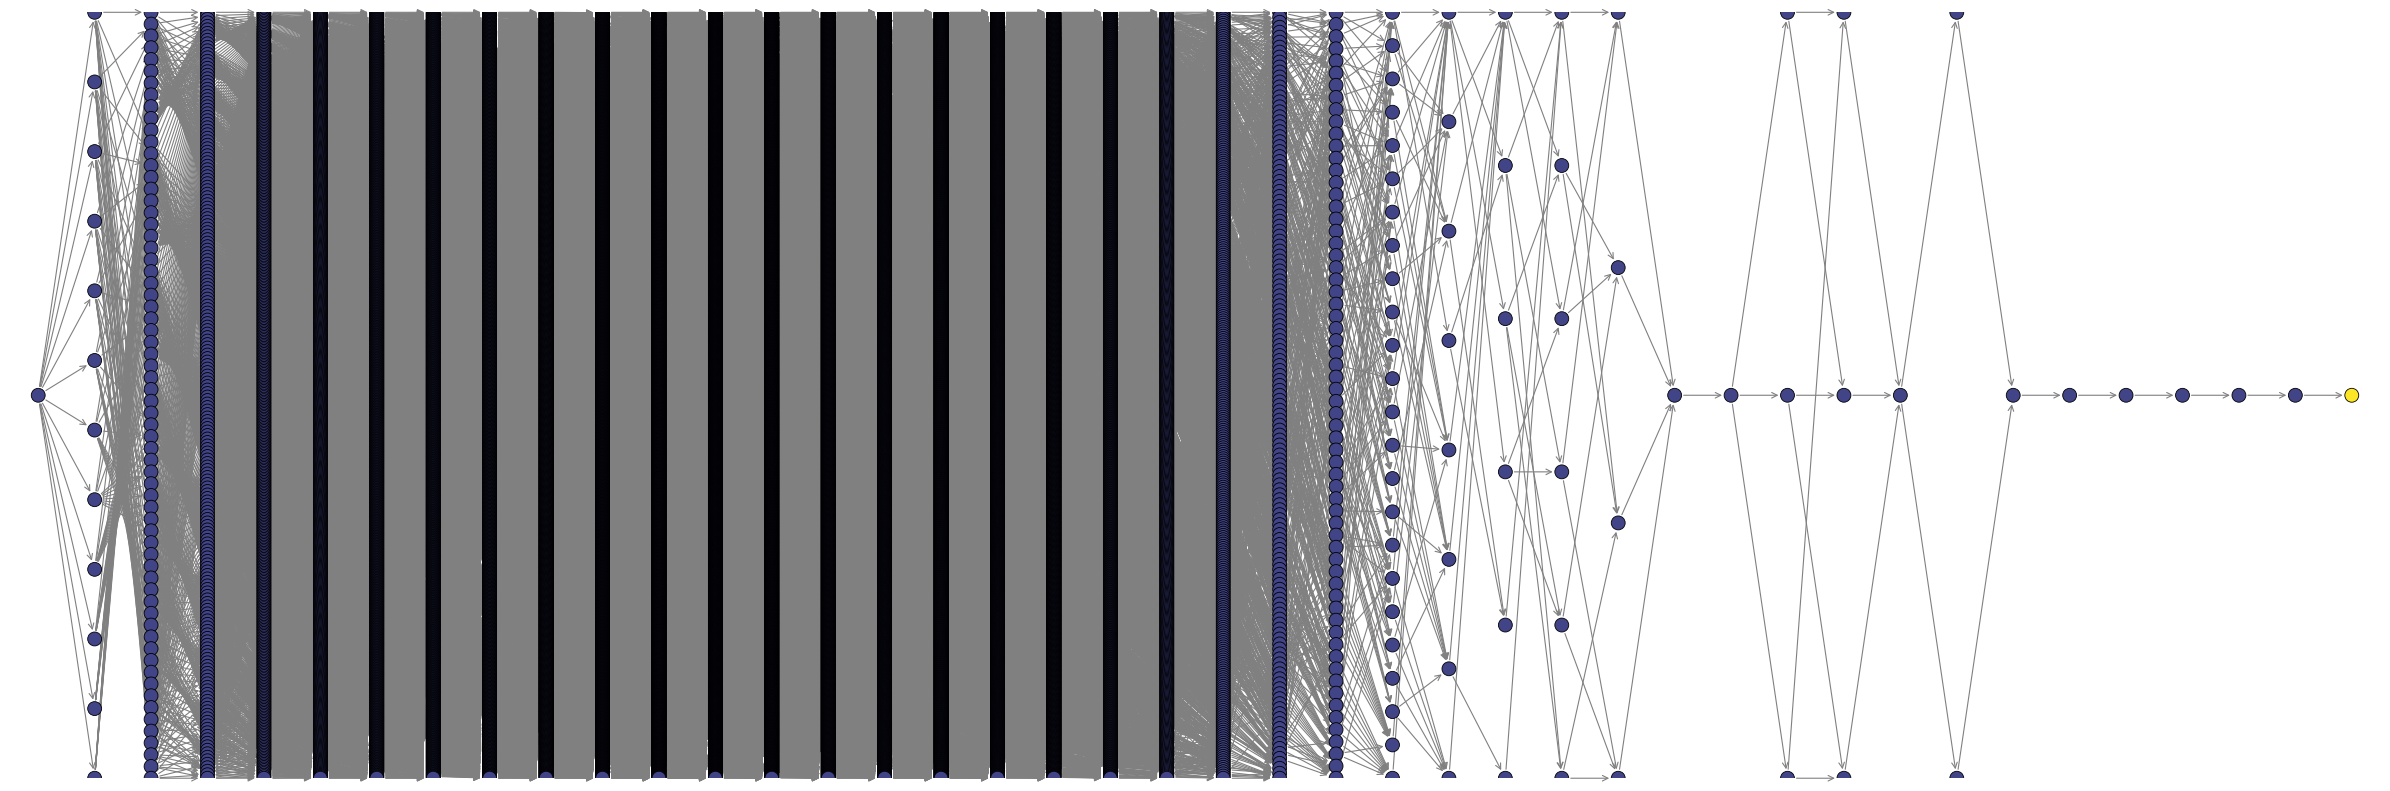

In [98]:
from src.plotting import plot_wigm_graph

plot_wigm_graph(
    constructor,
    figsize=(24, 8),
    node_size=100,
    font_size=14,
    label_edges=None,
    #label_vertices=True,
    #lam_restriction=670,
    plot_horizontal=True,
    title="",
    #title="Portland D2 (15 candidates, 3 seats, N_votes =42678, Margin=2000)"
)

In [7]:
constructor.lookup_vertex("I0")

Vertex I0
  ref: VertexRef(layer=8, local_id=0)
  status: EXPANDED
  degree: 0
  color: 0
  path_multiplicity: 6
  tightest_margin: 0.0
  seated winners:
  hopefuls:
    0: Steph Routh
    2: Jamie Dunphy
    4: Doug Clove
    5: Candace Avalos
    9: Terrence Hayes
    11: Noah Ernst
    12: Timur Ender
    14: Loretta Smith
  tallies:
    0: Steph Routh -> 4332.0
    1: Thomas Shervey -> 0.0
    2: Jamie Dunphy -> 5483.0
    3: Joe Furi -> 0.0
    4: Doug Clove -> 2403.0
    5: Candace Avalos -> 9237.0
    6: Michael (Mike) Sands -> 0.0
    7: Cayle Tern -> 0.0
    8: Peggy Sue Owens -> 0.0
    9: Terrence Hayes -> 4525.0
    10: David Linn -> 0.0
    11: Noah Ernst -> 4642.0
    12: Timur Ender -> 4187.0
    13: Deian Salazar -> 0.0
    14: Loretta Smith -> 6399.0
    15: Joe Allen -> 0.0


ElectionState(ref=VertexRef(layer=8, local_id=0), key=StateKey(seated_at=(None, None, None), hopefuls=frozenset({0, 2, 4, 5, 9, 11, 12, 14})), degree=0, tallies=array([4332.,    0., 5483.,    0., 2403., 9237.,    0.,    0.,    0.,
       4525.,    0., 4642., 4187.,    0., 6399.,    0.]), status=<ElectionStatus.EXPANDED: 1>, color=0, path_multiplicity=6, tightest_margin=0.0)

In [24]:
constructor.root_wt_vec

array([70.,  3.,  1., ...,  2.,  1.,  1.], shape=(18723,))

In [9]:
import numpy as np
import pandas as pd
A = constructor.ballot_matrix
def numpy_ballot_matrix_to_profile(numpy_matrix, M, wt_vec=None) -> RankProfile:
    """
    Re-used from the get_profile method I wrote for votekit's STV suite.
    """

    if wt_vec is None:
        wt_vec = np.ones(numpy_matrix.shape[0], dtype=np.float64)  # default weight vector of all 1s

    # make candidates an alphanumeric list of length M: ['A', 'B', 'C', ...]
    candidates = [chr(ord('A') + i) for i in range(M)]

    idx_to_fset = {c: frozenset([candidates[c]]) for c in range(M)}

    # --- 1) drop last column by view (sentinel column) ---
    #A = numpy_matrix[:, :-1]

    n_rows, n_cols = numpy_matrix.shape

    # --- 2) keep only entries in `remaining` ---
    remaining_arr = np.array(range(M), dtype=np.int64)  # all candidates are remaining in this context
    keep_mask = np.isin(numpy_matrix, remaining_arr)

    out = numpy_matrix.copy()  # make a copy to avoid modifying the original matrix

    # --- 3.5) drop rows that are empty after filtering AND rows with weight 0 ---
    # keep rows that have at least one remaining candidate and nonzero weight
    row_keep_mask = ~(out == -127).all(axis=1) & (wt_vec != 0)
    out = out[row_keep_mask]
    wt_vec = wt_vec[row_keep_mask]
    n_rows = out.shape[0]

    # --- 4) int8 -> frozenset mapping via 256-entry LUT ---
    # default for anything missing (including -127): frozenset("~")
    lut: np.ndarray = np.empty(256, dtype=object)
    lut[:] = frozenset(["~"])
    for k, v in idx_to_fset.items():
        lut[int(np.int16(k)) + 128] = v
    # index into LUT (shift by +128 to map [-128,127] -> [0,255])
    obj = lut[out.astype(np.int16, copy=False) + 128]  # dtype=object, frozensets

    # --- 5) to DataFrame with Ranking_i columns ---
    data = {f"Ranking_{i+1}": obj[:, i] for i in range(n_cols)}
    df = pd.DataFrame(data)

    # --- 6) Ballot Index column & set as index ---
    df.insert(0, "Ballot Index", np.arange(n_rows, dtype=int))
    df.set_index("Ballot Index", inplace=True)

    # --- 7) Voter Set: empty set per row (distinct objects) ---
    df["Voter Set"] = pd.Series([set() for _ in range(n_rows)], dtype=object, index=df.index)

    # --- 8) Weight column ---
    df["Weight"] = wt_vec.astype(np.float64, copy=False)

    return RankProfile(
        max_ranking_length=n_cols,
        candidates=tuple(candidates),
        df=df,
    )

In [8]:
import numpy as np

strong_candidates = np.array([0, 2, 4, 5, 9, 11, 12, 14], dtype=np.int8)
sentinel = np.int8(-127)

A = constructor.ballot_matrix.copy()
wt_vec = constructor.root_wt_vec.copy()

def compact_strong_fpv_rows_loop(ballot_matrix, strong_candidates, sentinel=-127):
    strong_set = set(np.asarray(strong_candidates).tolist())
    out = ballot_matrix.copy()
    num_strong_fpv = 0

    for i in range(out.shape[0]):
        if out[i, 0] in strong_set:
            num_strong_fpv += 1
            for j in range(1, out.shape[1]):
                if out[i, j] not in strong_set:
                    out[i, j] = sentinel

            keep_mask = out[i] != sentinel
            out[i] = np.concatenate([out[i][keep_mask], out[i][~keep_mask]])

    return out, num_strong_fpv

def compact_strong_fpv_rows(ballot_matrix, strong_candidates, sentinel=-127):
    out = ballot_matrix.copy()
    strong_candidates = np.asarray(strong_candidates, dtype=out.dtype)
    strong_fpv_mask = np.isin(out[:, 0], strong_candidates)

    suffix_keep_mask = np.isin(out[:, 1:], strong_candidates)
    out[strong_fpv_mask, 1:] = np.where(
        suffix_keep_mask[strong_fpv_mask],
        out[strong_fpv_mask, 1:],
        sentinel,
    )

    for row_idx in np.flatnonzero(strong_fpv_mask):
        keep_mask = out[row_idx] != sentinel
        out[row_idx] = np.concatenate([out[row_idx][keep_mask], out[row_idx][~keep_mask]])

    return out, int(strong_fpv_mask.sum())

def deduplicate_ballot_rows(ballot_matrix, wt_vec):
    contiguous_ballots = np.ascontiguousarray(ballot_matrix)
    row_view = contiguous_ballots.view(
        np.dtype((np.void, contiguous_ballots.dtype.itemsize * contiguous_ballots.shape[1]))
    ).ravel()

    _, first_idx, inverse = np.unique(
        row_view,
        return_index=True,
        return_inverse=True,
    )

    deduped_wt_vec = np.zeros(len(first_idx), dtype=wt_vec.dtype)
    np.add.at(deduped_wt_vec, inverse, wt_vec)

    order = np.argsort(first_idx)
    return contiguous_ballots[first_idx[order]], deduped_wt_vec[order]

loop_compacted_A, expected_num_strong_fpv = compact_strong_fpv_rows_loop(
    A, strong_candidates, sentinel=sentinel
 )
compacted_A, num_strong_fpv = compact_strong_fpv_rows(
    A, strong_candidates, sentinel=sentinel
 )

assert num_strong_fpv == expected_num_strong_fpv
assert np.array_equal(compacted_A, loop_compacted_A)

deduped_A, deduped_wt_vec = deduplicate_ballot_rows(compacted_A, wt_vec)

assert np.isclose(deduped_wt_vec.sum(), wt_vec.sum())

print(f"Strong-FPV rows compacted: {num_strong_fpv}")
print(f"Rows before deduplication: {compacted_A.shape[0]}")
print(f"Rows after deduplication: {deduped_A.shape[0]}")
print(f"Duplicate rows removed: {compacted_A.shape[0] - deduped_A.shape[0]}")
print(f"Weight preserved: {np.isclose(deduped_wt_vec.sum(), wt_vec.sum())}")

# If you want these simplified arrays to replace the constructor data, use:
# constructor.ballot_matrix = deduped_A
# constructor.root_wt_vec = deduped_wt_vec

Strong-FPV rows compacted: 14738
Rows before deduplication: 18723
Rows after deduplication: 8648
Duplicate rows removed: 10075
Weight preserved: True


In [13]:
import numpy as np

# Ballot matrix + weights
A = constructor.ballot_matrix.copy().astype(np.int16, copy=False)  # int16 for safe ops
wt_vec = constructor.root_wt_vec.copy()
M = len(constructor.candidate_names) # adjust if your object uses a different attribute
PAD = -127

# Define strata (fixed typo in strata_2: [0,11,9,5,12])
strata_0 = [2]
strata_1 = [14]
strata_2 = [0, 11, 9, 5, 12]
strata_3 = [4]

assigned = set(strata_0 + strata_1 + strata_2 + strata_3)
strata_4 = [c for c in range(M) if c not in assigned]  # everyone else

strata = [strata_0, strata_1, strata_2, strata_3, strata_4]
cand_to_stratum = {c: s for s, group in enumerate(strata) for c in group}

def clean_by_strata(ballot_matrix: np.ndarray, pad: int = -127) -> np.ndarray:
    """
    Rule:
    scanning left->right, once an earlier stratum has appeared,
    any later-stratum candidate that appears after that is erased.
    Then row is compacted left, padding with `pad`.
    """
    out = ballot_matrix.copy()

    for r in range(out.shape[0]):
        row = out[r]
        min_seen = 10**9

        # erase offending entries
        for j, cand in enumerate(row):
            if cand == pad:
                continue
            s = cand_to_stratum.get(int(cand), len(strata) - 1)
            if s < min_seen:
                min_seen = s
            elif s > min_seen:
                row[j] = pad

        # compact left (remove internal pads, keep order)
        kept = row[row != pad]
        row[:] = pad
        row[:len(kept)] = kept

    return out.astype(np.int8, copy=False)

compacted_A = clean_by_strata(A, pad=PAD)

assert num_strong_fpv == expected_num_strong_fpv


deduped_A, deduped_wt_vec = deduplicate_ballot_rows(compacted_A, wt_vec)

assert np.isclose(deduped_wt_vec.sum(), wt_vec.sum())

print(f"Strong-FPV rows compacted: {num_strong_fpv}")
print(f"Rows before deduplication: {compacted_A.shape[0]}")
print(f"Rows after deduplication: {deduped_A.shape[0]}")
print(f"Duplicate rows removed: {compacted_A.shape[0] - deduped_A.shape[0]}")
print(f"Weight preserved: {np.isclose(deduped_wt_vec.sum(), wt_vec.sum())}")


Strong-FPV rows compacted: 14738
Rows before deduplication: 18723
Rows after deduplication: 2832
Duplicate rows removed: 15891
Weight preserved: True
